In [17]:
# importing necessary libraries
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

In [18]:
print(os.getcwd())



C:\Users\Samreet\HackthonRepoMerged\Team6_PyForce_PythonHackathon_SEP2026\notebooks


In [20]:
#Read the CSV from the data folder
df = pd.read_csv("../data/final/Team6_PyForce_cleaned_data.csv")


**Q1: What is the gender split, and how does it vary by age category?**

Reason: To establish the demographic baseline of the cohort, to understand who the patients are in terms of age distribution and gender split.

gender
Female    1163
Male       845
Name: count, dtype: int64
gender
Female    57.9
Male      42.1
Name: proportion, dtype: float64
gender        Female  Male
age_category              
21-29              3     1
30-39              5     7
40-49             18    38
50-59             51    55
60-69            190   178
70-79            421   294
80-89            409   237
90-110            66    35
gender        Female  Male
age_category              
21-29           75.0  25.0
30-39           41.7  58.3
40-49           32.1  67.9
50-59           48.1  51.9
60-69           51.6  48.4
70-79           58.9  41.1
80-89           63.3  36.7
90-110          65.3  34.7


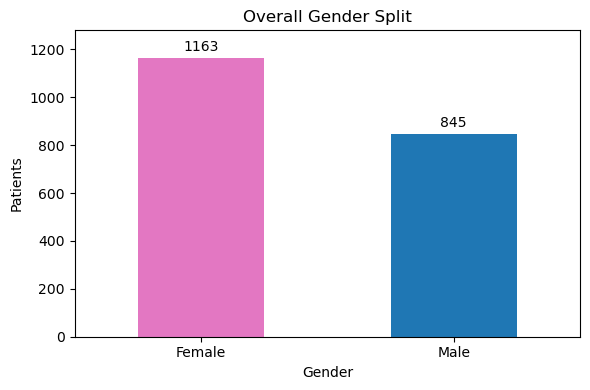

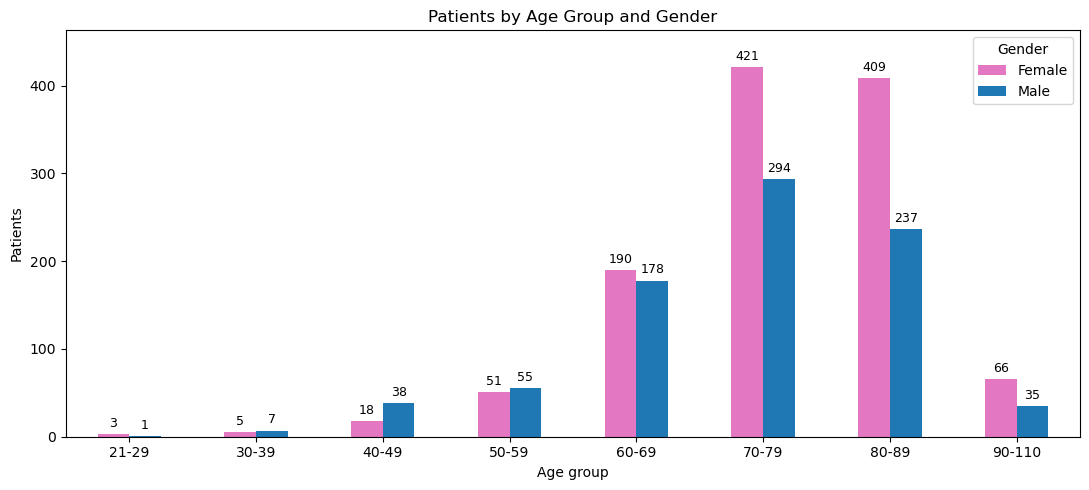

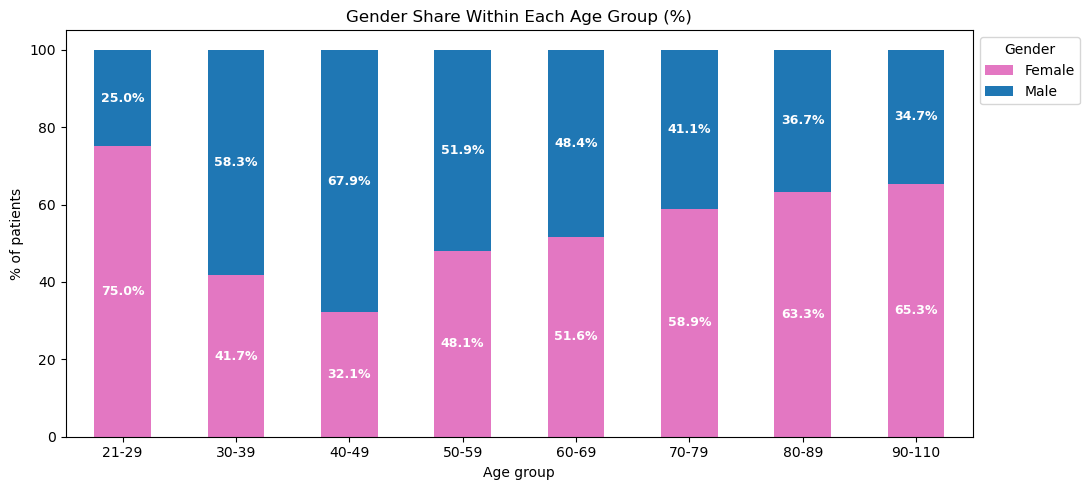

In [21]:
import matplotlib.pyplot as plt

# Overall gender split
gender_counts = df["gender"].value_counts()
gender_pct = df["gender"].value_counts(normalize=True) * 100
print(gender_counts)
print(gender_pct.round(1))

# Gender split by age category — counts
gender_by_age = pd.crosstab(df["age_category"], df["gender"])
print(gender_by_age)

# Gender split by age category — as row percentages (share within each age group)
gender_by_age_pct = pd.crosstab(df["age_category"], df["gender"], normalize="index") * 100
print(gender_by_age_pct.round(1))

# Bar graph 1 — overall gender split
ax = gender_counts.plot(kind="bar", figsize=(6, 4), color=["#e377c2", "#1f77b4"])
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.title("Overall Gender Split")
plt.xlabel("Gender")
plt.ylabel("Patients")
plt.xticks(rotation=0)
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph 2 — gender by age category (counts)
ax = gender_by_age.plot(kind="bar", figsize=(11, 5), color=["#e377c2", "#1f77b4"])
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
plt.title("Patients by Age Group and Gender")
plt.xlabel("Age group")
plt.ylabel("Patients")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph 3 — gender share within each age group (stacked %)
ax = gender_by_age_pct.plot(kind="bar", stacked=True, figsize=(11, 5), color=["#e377c2", "#1f77b4"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=9, color="white", fontweight="bold")
plt.title("Gender Share Within Each Age Group (%)")
plt.xlabel("Age group")
plt.ylabel("% of patients")
plt.xticks(rotation=0)
plt.legend(title="Gender", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**Analysis:**
Out of 2,008 patients (57.9% female, 42.1% male, males dominating younger brackets and females making up 65.3% of the oldest group.Strategies must account for a significant demographic shift, focusing on large majority of elderly women over 70

**Q2:What are the most common cardiac complications among patients?**

Reason: This step identifies the most common heart complications in our patient population and provides a foundation for analyzing patient severity,responsiveness,and outcomes.

                         patients     %
congestive_hf                1872  93.2
heart_attack                  143   7.1
peripheral_vasc_disease       101   5.0
hf_type
Both     1480
Left      477
Right      51
Name: count, dtype: int64
nyha_class
2     353
3    1039
4     616
Name: count, dtype: int64
killip_grade
1     527
2    1029
3     392
4      60
Name: count, dtype: int64
        congestive_hf  heart_attack  peripheral_vasc_disease
gender                                                      
Female           93.0           5.7                      4.6
Male             93.5           9.1                      5.6
moderate_to_severe_chronic_kidney_disease    23.6
diabetes                                     23.2
chronic_obstructive_pulmonary_disease        11.6
cerebrovascular_disease                       7.5
type_2_respiratory_failure_Binary             5.7
acute_renal_failure                           0.3
dtype: float64


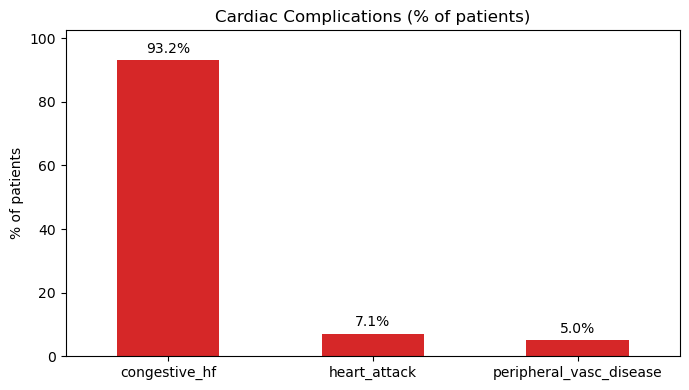

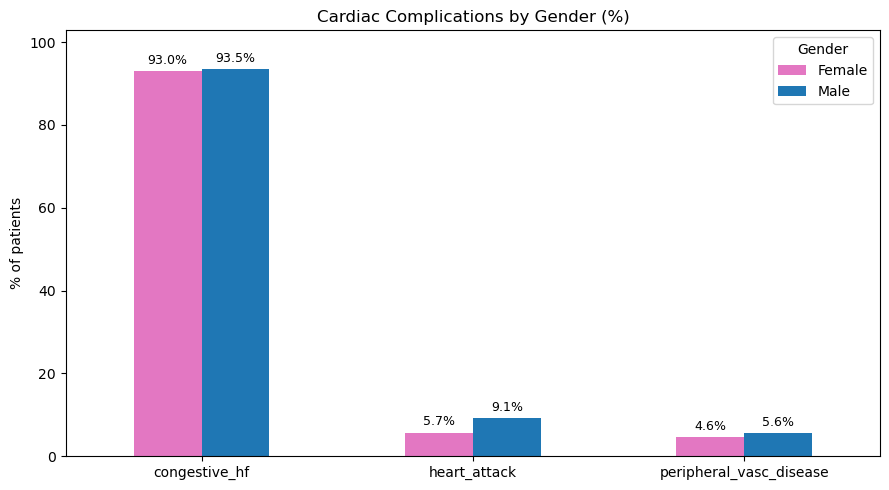

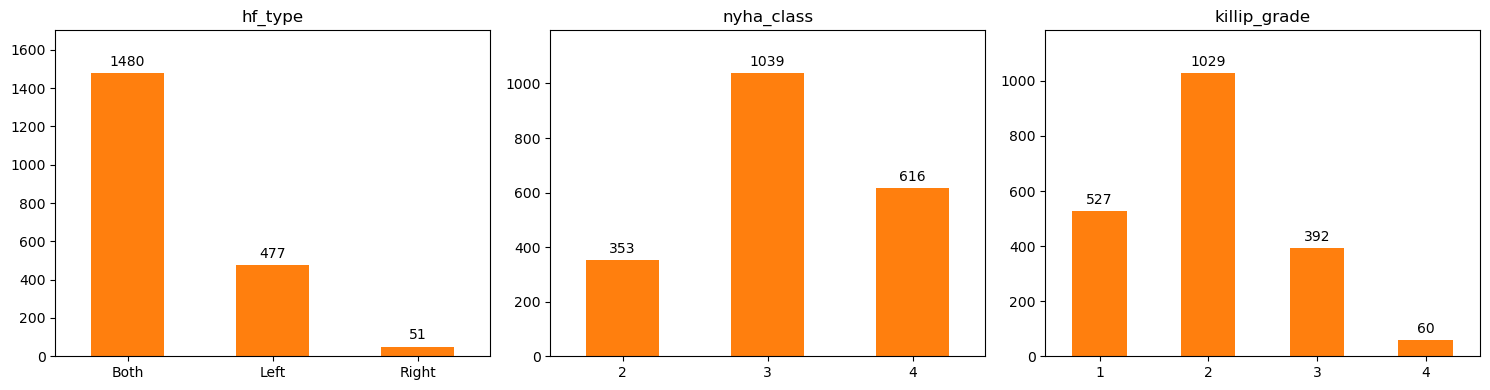

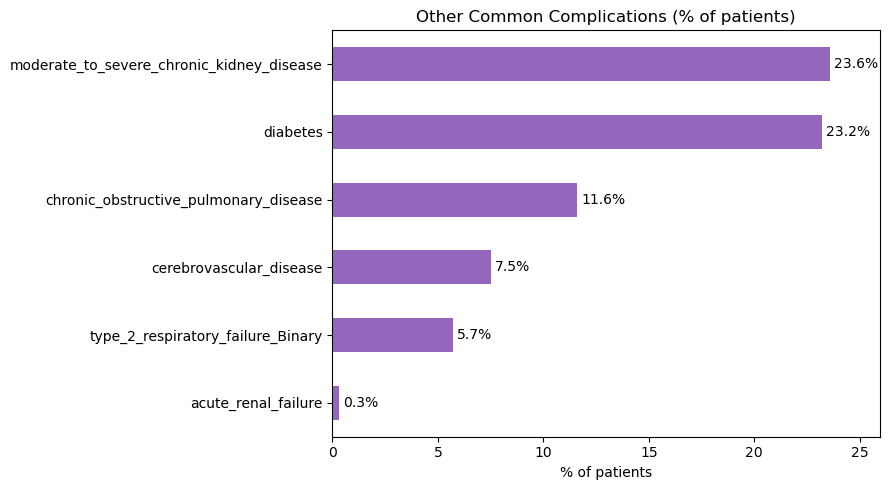

In [22]:
import matplotlib.pyplot as plt

# Cardiac complications — counts and %
cardiac_cols = ["congestive_hf", "heart_attack", "peripheral_vasc_disease"]
cardiac_counts = df[cardiac_cols].sum().sort_values(ascending=False)
cardiac_pct = (df[cardiac_cols].mean() * 100).round(1).sort_values(ascending=False)
print(pd.DataFrame({"patients": cardiac_counts, "%": cardiac_pct}))

# Heart failure type, NYHA class, Killip grade
print(df["hf_type"].value_counts())
print(df["nyha_class"].value_counts().sort_index())
print(df["killip_grade"].value_counts().sort_index())

# Cardiac complications by gender (%)
print((df.groupby("gender")[cardiac_cols].mean() * 100).round(1))

# Other common complications (%)
other_cols = ["moderate_to_severe_chronic_kidney_disease", "diabetes",
              "chronic_obstructive_pulmonary_disease", "cerebrovascular_disease",
              "type_2_respiratory_failure_Binary", "acute_renal_failure"]
other_pct = (df[other_cols].mean() * 100).round(1).sort_values(ascending=False)
print(other_pct)

# Bar graph 1 — cardiac complications (%)
ax = cardiac_pct.plot(kind="bar", figsize=(7, 4), color="#d62728")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("Cardiac Complications (% of patients)")
plt.ylabel("% of patients")
plt.xticks(rotation=0)
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph 2 — cardiac complications by gender (%)
cardiac_by_gender = (df.groupby("gender")[cardiac_cols].mean() * 100).round(1).T
ax = cardiac_by_gender.plot(kind="bar", figsize=(9, 5), color=["#e377c2", "#1f77b4"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
plt.title("Cardiac Complications by Gender (%)")
plt.ylabel("% of patients")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph 3 — HF type, NYHA class, Killip grade (counts)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["hf_type", "nyha_class", "killip_grade"]):
    counts = df[col].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="#ff7f0e")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.margins(y=0.15)
plt.tight_layout()
plt.show()

# Bar graph 4 — other common complications (%)
ax = other_pct.sort_values().plot(kind="barh", figsize=(9, 5), color="#9467bd")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("Other Common Complications (% of patients)")
plt.xlabel("% of patients")
plt.margins(x=0.1)
plt.tight_layout()
plt.show()

**Analysis:**
Congestive heart failure is the primary complication affecting 93.2% of patients with over 80% of patients classified in advanced functional stages (NYHA Class 3 or 4).

Heart failure indicates a critically ill patient baseline that demands highly intensive medical management.

**Q3:What are the most common comorbidities in the cohort?**

Reason: After identifying the main cardiac complications, we look at other existing health conditions that may be associated with disease severity, responsiveness, readmission, and mortality.

                                           patients     %  missing
moderate_to_severe_chronic_kidney_disease       474  23.6        2
diabetes                                        466  23.2        0
chronic_obstructive_pulmonary_disease           233  11.6        0
cerebrovascular_disease                         150   7.5        0
dementia                                        115   5.7        0
liver_disease                                    84   4.2        1
peptic_ulcer_disease                             45   2.2        2
solid_tumor                                      39   1.9        0
hemiplegia                                       12   0.6        0
connective_tissue_disease                         4   0.2        0
aids                                              4   0.2        0
malignant_lymphoma                                1   0.0        0
leukemia                                          0   0.0        0
comorbidity_count
0    845
1    774
2    320
3     63
4      6

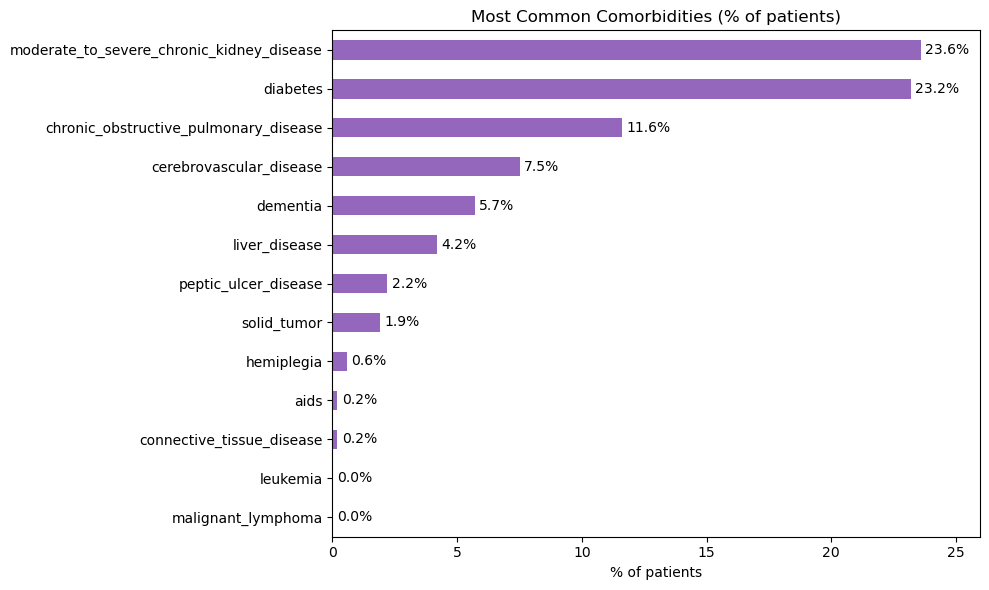

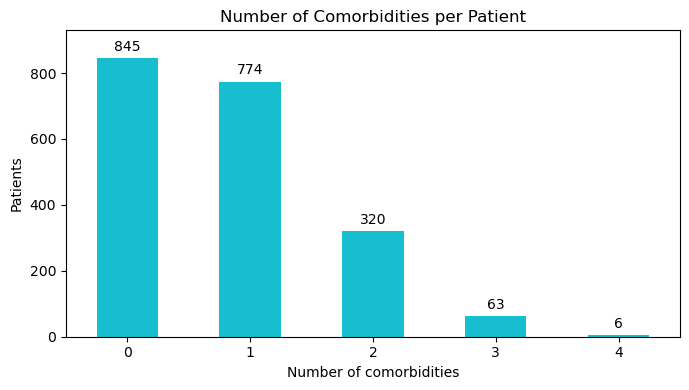

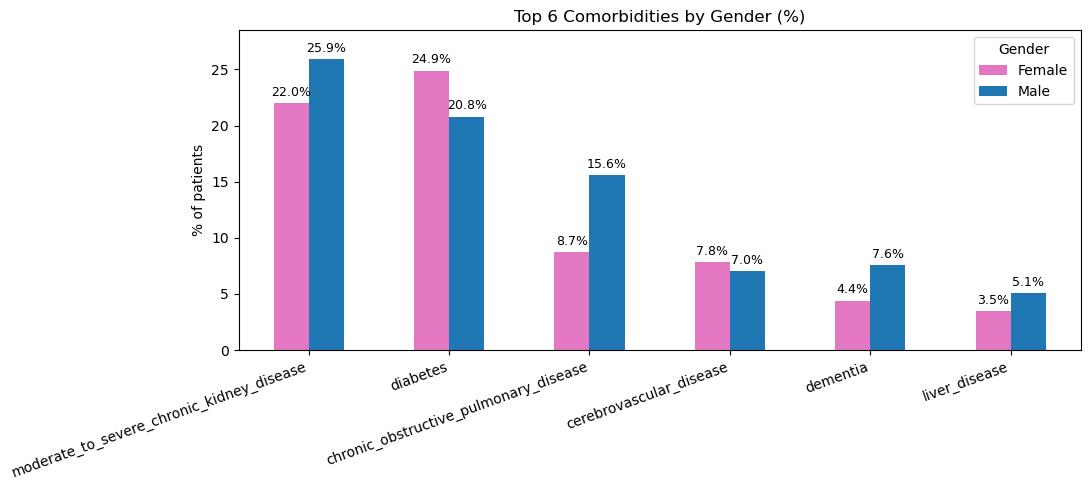

In [23]:
import matplotlib.pyplot as plt

# Non-cardiac comorbidities
comorbidities = ["moderate_to_severe_chronic_kidney_disease", "diabetes",
                 "chronic_obstructive_pulmonary_disease", "cerebrovascular_disease",
                 "dementia", "liver_disease", "peptic_ulcer_disease", "solid_tumor",
                 "hemiplegia", "connective_tissue_disease", "aids",
                 "malignant_lymphoma", "leukemia"]

# Prevalence — counts and %
comorb_table = pd.DataFrame({
    "patients": df[comorbidities].sum().astype(int),
    "%": (df[comorbidities].mean() * 100).round(1),
    "missing": df[comorbidities].isna().sum()
}).sort_values("patients", ascending=False)
print(comorb_table)

# Number of comorbidities per patient
df["comorbidity_count"] = df[comorbidities].fillna(0).sum(axis=1).astype(int)
comorb_count = df["comorbidity_count"].value_counts().sort_index()
print(comorb_count)
print("At least 1:", round((df["comorbidity_count"] >= 1).mean() * 100, 1), "%")
print("2 or more:", round((df["comorbidity_count"] >= 2).mean() * 100, 1), "%")

# Comorbidities by gender (%)
comorb_by_gender = (df.groupby("gender")[comorbidities].mean() * 100).round(1).T
print(comorb_by_gender)

# Bar graph 1 — comorbidity prevalence (%)
ax = comorb_table["%"].sort_values().plot(kind="barh", figsize=(10, 6), color="#9467bd")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
plt.title("Most Common Comorbidities (% of patients)")
plt.xlabel("% of patients")
plt.margins(x=0.1)
plt.tight_layout()
plt.show()

# Bar graph 2 — number of comorbidities per patient
ax = comorb_count.plot(kind="bar", figsize=(7, 4), color="#17becf")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.title("Number of Comorbidities per Patient")
plt.xlabel("Number of comorbidities")
plt.ylabel("Patients")
plt.xticks(rotation=0)
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph 3 — top 6 comorbidities by gender (%)
top6 = comorb_table.index[:6]
ax = comorb_by_gender.loc[top6].plot(kind="bar", figsize=(11, 5), color=["#e377c2", "#1f77b4"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
plt.title("Top 6 Comorbidities by Gender (%)")
plt.ylabel("% of patients")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Gender")
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

**Analysis:**
Chronic kidney disease (23.6%) and diabetes (23.2%) are the top comorbidities where 57.9% of patients suffer from at least one non-cardiac condition. Naerly a quarter of the population faces the risks of kidney and diabetes disease, hence they require an integrated, multidisciplinary approach

**Q4: How severe are the cardiac conditions among patients?**

Reason:This step helps us understand how serious the patients’ heart conditions are using measures such as NYHA class, Killip grade, and ejection fraction.


nyha_class:
            patients     %
nyha_class                
2                353  17.6
3               1039  51.7
4                616  30.7

killip_grade:
              patients     %
killip_grade                
1                  527  26.2
2                 1029  51.2
3                  392  19.5
4                   60   3.0

hf_type:
         patients     %
hf_type                
Both         1480  73.7
Left          477  23.8
Right          51   2.5

Severe cardiac (NYHA IV or Killip III-IV): 874 (43.5%)
killip_grade    1     2    3   4   All
nyha_class                            
2             136   151   66   0   353
3             304   543  190   2  1039
4              87   335  136  58   616
All           527  1029  392  60  2008
gender      Female  Male
nyha_class              
2             19.4  15.0
3             52.3  51.0
4             28.3  34.0
gender        Female  Male
killip_grade              
1               28.0  23.8
2               50.5  52.3
3         

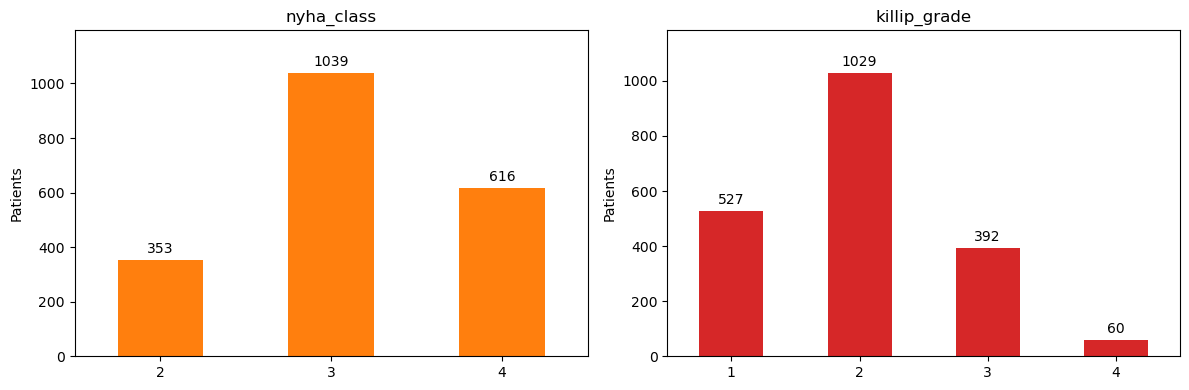

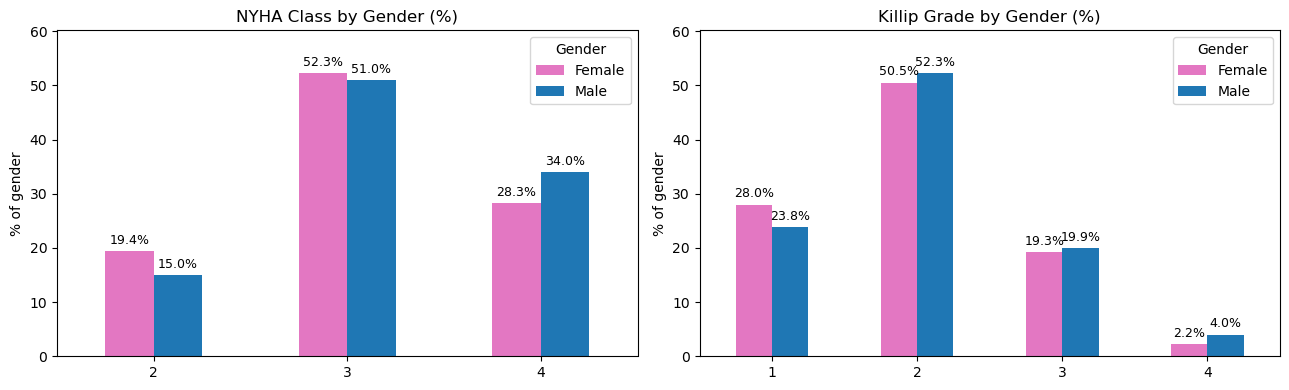

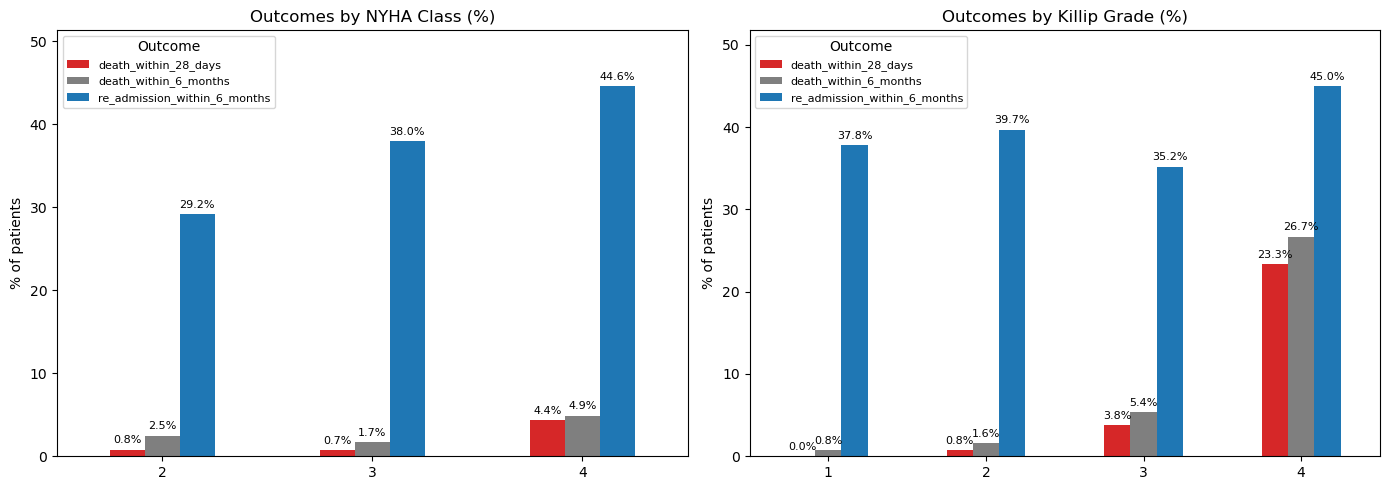

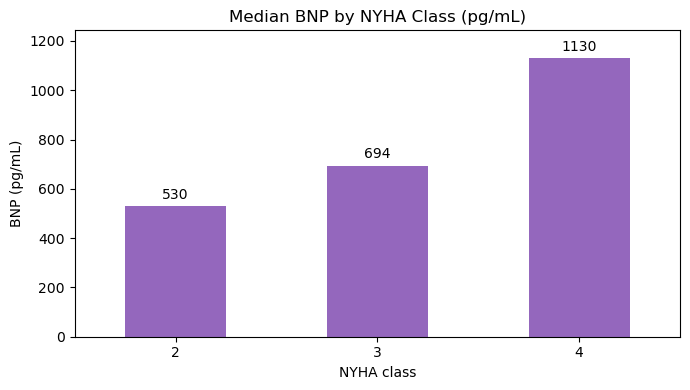

In [24]:
import matplotlib.pyplot as plt

outcome_cols = ["death_within_28_days", "death_within_6_months", "re_admission_within_6_months"]

# NYHA class, Killip grade, HF type — counts and %
for col in ["nyha_class", "killip_grade", "hf_type"]:
    table = pd.DataFrame({
        "patients": df[col].value_counts().sort_index(),
        "%": (df[col].value_counts(normalize=True).sort_index() * 100).round(1)
    })
    print(f"\n{col}:")
    print(table)

# Overall severe group: NYHA IV or Killip III-IV
df["severe_cardiac"] = ((df["nyha_class"] == 4) | (df["killip_grade"] >= 3)).astype(int)
print("\nSevere cardiac (NYHA IV or Killip III-IV):", df["severe_cardiac"].sum(),
      f"({df['severe_cardiac'].mean() * 100:.1f}%)")

# NYHA vs Killip
print(pd.crosstab(df["nyha_class"], df["killip_grade"], margins=True))

# Severity by gender (% of each gender)
nyha_gender = (pd.crosstab(df["nyha_class"], df["gender"], normalize="columns") * 100).round(1)
killip_gender = (pd.crosstab(df["killip_grade"], df["gender"], normalize="columns") * 100).round(1)
print(nyha_gender)
print(killip_gender)

# Outcomes by severity (%)
nyha_outcomes = (df.groupby("nyha_class")[outcome_cols].mean() * 100).round(1)
killip_outcomes = (df.groupby("killip_grade")[outcome_cols].mean() * 100).round(1)
print(nyha_outcomes)
print(killip_outcomes)

# BNP by NYHA class
print("\nBNP median by NYHA class:")
print(df.groupby("nyha_class")["brain_natriuretic_peptide"].median().round(1))
print("BNP capped at 5000:", (df["brain_natriuretic_peptide"] == 5000).sum())

# Ejection fraction groups (note: most values missing)
print(f"\nEjection fraction missing: {df['ejection_fraction'].isna().mean() * 100:.1f}%")
df["ef_group"] = pd.cut(df["ejection_fraction"], bins=[0, 40, 49, 100],
                        labels=["HFrEF (<=40)", "HFmrEF (41-49)", "HFpEF (>=50)"])
print(df["ef_group"].value_counts().sort_index())

# Bar graph 1 — NYHA and Killip (counts)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ["nyha_class", "killip_grade"], ["#ff7f0e", "#d62728"]):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax, color=color)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Patients")
    ax.tick_params(axis="x", rotation=0)
    ax.margins(y=0.15)
plt.tight_layout()
plt.show()

# Bar graph 2 — severity by gender (%)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, title in zip(axes, [nyha_gender, killip_gender], ["NYHA Class by Gender (%)", "Killip Grade by Gender (%)"]):
    data.plot(kind="bar", ax=ax, color=["#e377c2", "#1f77b4"])
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("% of gender")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Gender")
    ax.margins(y=0.15)
plt.tight_layout()
plt.show()

# Bar graph 3 — outcomes by NYHA and Killip (%)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes, [nyha_outcomes, killip_outcomes], ["Outcomes by NYHA Class (%)", "Outcomes by Killip Grade (%)"]):
    data.plot(kind="bar", ax=ax, color=["#d62728", "#7f7f7f", "#1f77b4"])
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("% of patients")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Outcome", fontsize=8)
    ax.margins(y=0.15)
plt.tight_layout()
plt.show()

# Bar graph 4 — median BNP by NYHA class
bnp_nyha = df.groupby("nyha_class")["brain_natriuretic_peptide"].median().round(0)
ax = bnp_nyha.plot(kind="bar", figsize=(7, 4), color="#9467bd")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.title("Median BNP by NYHA Class (pg/mL)")
plt.xlabel("NYHA class")
plt.ylabel("BNP (pg/mL)")
plt.xticks(rotation=0)
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

**Analysis:**
Killip grade 4 and NYHA class 4 act as critical, early red flags for imminent mortality, demanding immediate stabilization

**Q5: What is the level of responsiveness among cardiac patients?**

Reason: This step helps us understand how alert and responsive cardiac patients are using measures such as the Glasgow Coma Scale (GCS), consciousness, eye opening, verbal response, and movement.


eye_opening:
eye_opening
1      14
2       3
3      25
4    1966
Name: count, dtype: int64

verbal_response:
verbal_response
1      14
2       8
3      18
4       4
5    1964
Name: count, dtype: int64

movement:
movement
1      22
2       1
3       2
4       2
5      22
6    1959
Name: count, dtype: int64

glasgow_coma_scale:
glasgow_coma_scale
3       13
4        1
6        1
7        4
10       7
11      19
12       3
13       2
14       7
15    1951
Name: count, dtype: int64

GCS summary:
count    2008.00
mean       14.83
std         1.18
min         3.00
25%        15.00
50%        15.00
75%        15.00
max        15.00
Name: glasgow_coma_scale, dtype: float64
                   patients     %
consciousness                    
Clear                  1974  98.3
ResponsiveToSound        19   0.9
Nonresponsive            11   0.5
ResponsiveToPain          4   0.2
                    count  mean  std  min   25%   50%   75%   max
consciousness                                          

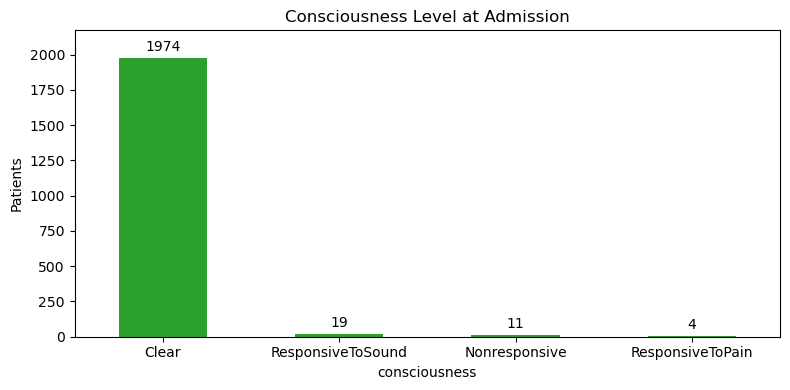

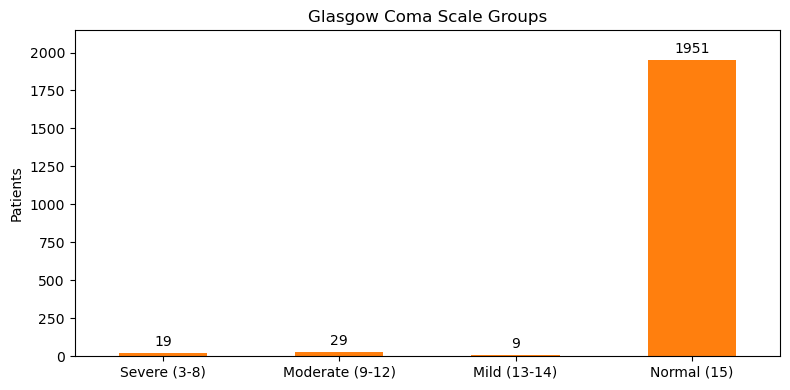

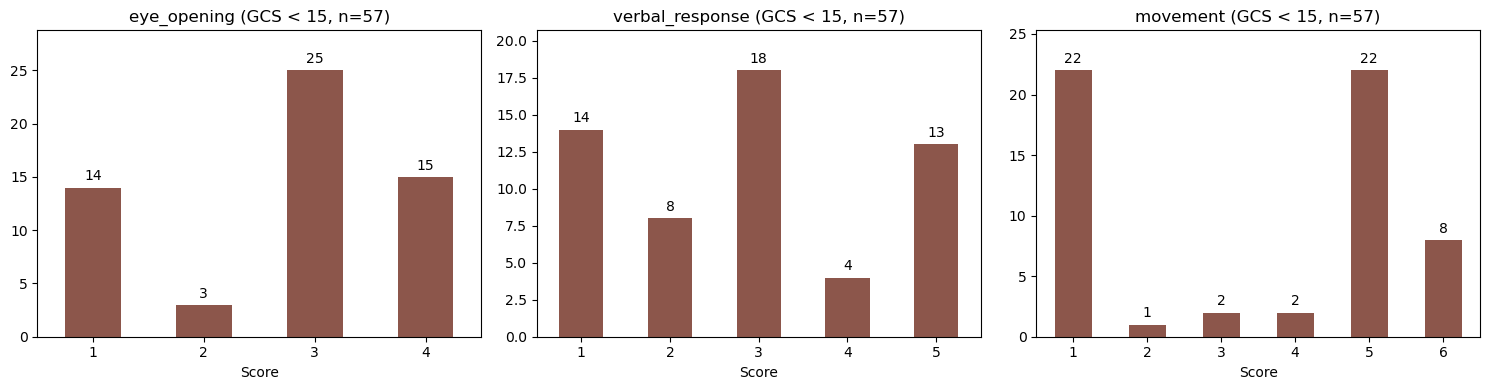

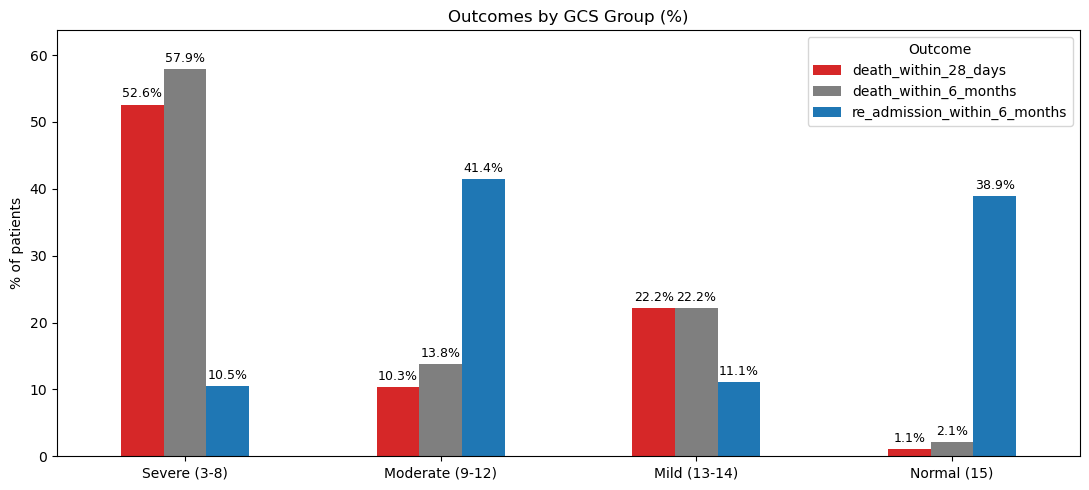

In [25]:
import matplotlib.pyplot as plt

# GCS components and total score
for col in ["eye_opening", "verbal_response", "movement", "glasgow_coma_scale"]:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())

print("\nGCS summary:")
print(df["glasgow_coma_scale"].describe().round(2))

# Consciousness level
consc_table = pd.DataFrame({
    "patients": df["consciousness"].value_counts(),
    "%": (df["consciousness"].value_counts(normalize=True) * 100).round(1)
})
print(consc_table)

# Check consciousness matches GCS
print(df.groupby("consciousness")["glasgow_coma_scale"].describe().round(1))
print("Mismatch flags:", df["consciousness_mismatch_flag"].sum())

# GCS severity groups
df["gcs_group"] = pd.cut(df["glasgow_coma_scale"], bins=[2, 8, 12, 14, 15],
                         labels=["Severe (3-8)", "Moderate (9-12)", "Mild (13-14)", "Normal (15)"])
gcs_table = pd.DataFrame({
    "patients": df["gcs_group"].value_counts().sort_index(),
    "%": (df["gcs_group"].value_counts(normalize=True).sort_index() * 100).round(1)
})
print(gcs_table)

# GCS group by gender
print(pd.crosstab(df["gcs_group"], df["gender"]))

# Outcomes by GCS group (%)
outcome_cols = ["death_within_28_days", "death_within_6_months", "re_admission_within_6_months"]
gcs_outcomes = (df.groupby("gcs_group", observed=True)[outcome_cols].mean() * 100).round(1)
print(gcs_outcomes)

# Bar graph 1 — consciousness level (counts)
ax = df["consciousness"].value_counts().plot(kind="bar", figsize=(8, 4), color="#2ca02c")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.title("Consciousness Level at Admission")
plt.ylabel("Patients")
plt.xticks(rotation=0)
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph 2 — GCS severity groups (counts)
ax = gcs_table["patients"].plot(kind="bar", figsize=(8, 4), color="#ff7f0e")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.title("Glasgow Coma Scale Groups")
plt.ylabel("Patients")
plt.xlabel("")
plt.xticks(rotation=0)
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph 3 — GCS components among patients with GCS < 15
low_gcs = df[df["glasgow_coma_scale"] < 15]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["eye_opening", "verbal_response", "movement"]):
    counts = low_gcs[col].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="#8c564b")
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)
    ax.set_title(f"{col} (GCS < 15, n={len(low_gcs)})")
    ax.set_xlabel("Score")
    ax.tick_params(axis="x", rotation=0)
    ax.margins(y=0.15)
plt.tight_layout()
plt.show()

# Bar graph 4 — outcomes by GCS group (%)
ax = gcs_outcomes.plot(kind="bar", figsize=(11, 5), color=["#d62728", "#7f7f7f", "#1f77b4"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
plt.title("Outcomes by GCS Group (%)")
plt.ylabel("% of patients")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

**Analysis:**
97.2% of patients have a normal baseline responsiveness, the small subset (0.9%) presenting with severe neurological impairment faces a staggering 28-day mortality rate of 52.6%.Consciousness level at admission is an emergency indicator, serving as one of the strongest short-term predictors of patient mortality


**Q6: How does patient responsiveness vary across different cardiac complications?**

Reason:
This step helps us compare whether patients with different cardiac complications show different levels of responsiveness, using measures such as GCS, consciousness, eye opening, verbal response, and movement.


heart_attack:
              patients  mean_gcs  median_gcs  min_gcs  low_gcs_patients  \
heart_attack                                                              
0                 1865     14.83        15.0        3                49   
1                  143     14.83        15.0       11                 8   

              low_gcs_pct  
heart_attack               
0                     2.6  
1                     5.6  

congestive_hf:
               patients  mean_gcs  median_gcs  min_gcs  low_gcs_patients  \
congestive_hf                                                              
0                   136     14.94        15.0       11                 2   
1                  1872     14.82        15.0        3                55   

               low_gcs_pct  
congestive_hf               
0                      1.5  
1                      2.9  

peripheral_vasc_disease:
                         patients  mean_gcs  median_gcs  min_gcs  \
peripheral_vasc_disease                  

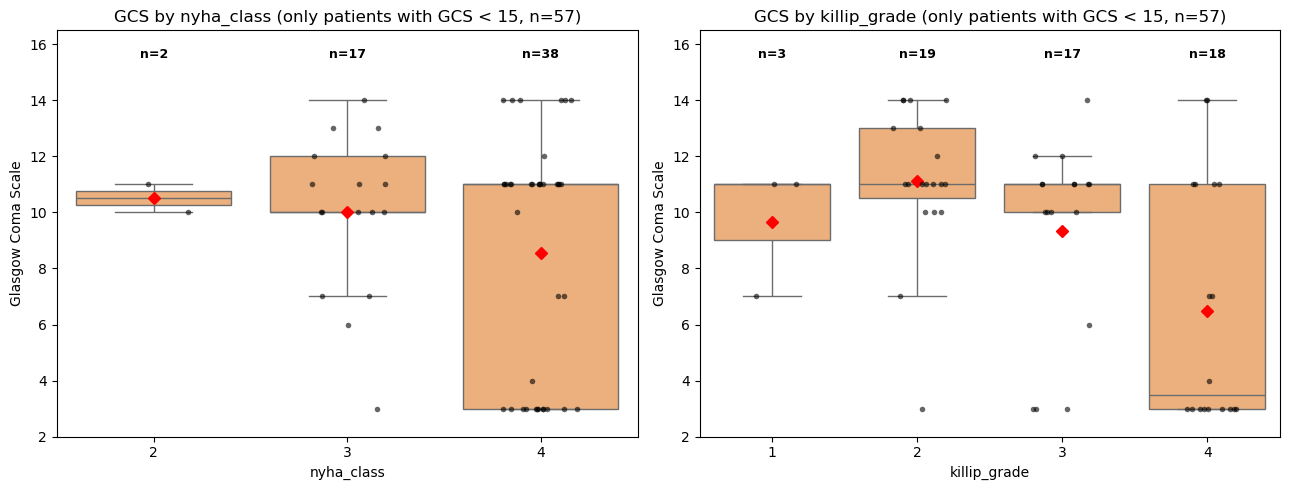

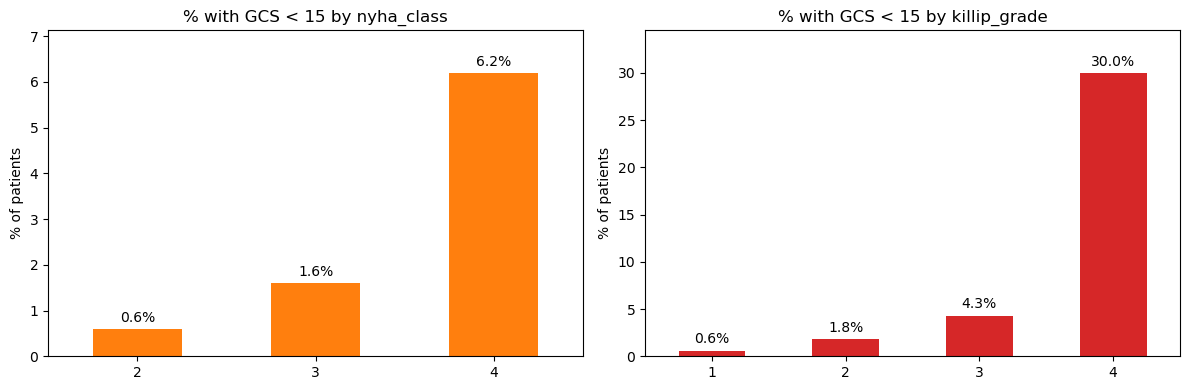

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cardiac complication columns
complication_cols = ["heart_attack", "congestive_hf", "peripheral_vasc_disease",
                     "hf_type", "nyha_class", "killip_grade"]

# Flag for reduced responsiveness (GCS below 15)
df["low_gcs"] = (df["glasgow_coma_scale"] < 15).astype(int)

# Summary table: GCS by each complication
for col in complication_cols:
    summary = df.groupby(col).agg(
        patients=("glasgow_coma_scale", "size"),
        mean_gcs=("glasgow_coma_scale", "mean"),
        median_gcs=("glasgow_coma_scale", "median"),
        min_gcs=("glasgow_coma_scale", "min"),
        low_gcs_patients=("low_gcs", "sum"),
        low_gcs_pct=("low_gcs", "mean"),
    )
    summary["mean_gcs"] = summary["mean_gcs"].round(2)
    summary["low_gcs_pct"] = (summary["low_gcs_pct"] * 100).round(1)
    print(f"\n{col}:")
    print(summary)

# Consciousness level by Killip grade
print(pd.crosstab(df["killip_grade"], df["consciousness"], margins=True))


# Boxplot 2 — only patients with reduced responsiveness (GCS < 15)
low = df[df["low_gcs"] == 1]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ["nyha_class", "killip_grade"]):
    sns.boxplot(data=low, x=col, y="glasgow_coma_scale", ax=ax, color="#fdae6b",
                showfliers=False, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "red",
                           "markeredgecolor": "red", "markersize": 6})
    sns.stripplot(data=low, x=col, y="glasgow_coma_scale", ax=ax, color="black",
                  size=4, alpha=0.6, jitter=0.2)
    groups = sorted(low[col].dropna().unique())
    for i, g in enumerate(groups):
        sub = low.loc[low[col] == g, "glasgow_coma_scale"]
        ax.text(i, 15.5, f"n={len(sub)}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"GCS by {col} (only patients with GCS < 15, n={len(low)})")
    ax.set_xlabel(col)
    ax.set_ylabel("Glasgow Coma Scale")
    ax.set_ylim(2, 16.5)
plt.tight_layout()
plt.show()

# Bar graph — % of patients with reduced responsiveness by NYHA and Killip
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, ["nyha_class", "killip_grade"], ["#ff7f0e", "#d62728"]):
    pct = (df.groupby(col)["low_gcs"].mean() * 100).round(1)
    pct.plot(kind="bar", ax=ax, color=color)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)
    ax.set_title(f"% with GCS < 15 by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("% of patients")
    ax.tick_params(axis="x", rotation=0)
    ax.margins(y=0.15)
plt.tight_layout()
plt.show()

**Analysis:**
Reduced responsiveness (GCS < 15) is twice as common in myocardial infarction (5.6%) than general heart failure, and spikes drastically to 30.0% in patients suffering from acute cardiogenic shock (Killip 4).These cardiac events making needs a vital part of emergency cardiac care.



**Q7:How do key labs and vital signs relate to each other and to BMI and age?**

Reason:
This step helps us identify patterns and relationships between important clinical measurements, such as lab results, vital signs, BMI, and age.

Missing values:
age_numeric                      0
bmi                              0
pulse                            0
respiration                      0
systolic_blood_pressure          4
diastolic_blood_pressure         4
body_temperature                 0
brain_natriuretic_peptide       35
high_sensitivity_troponin       79
creatinine_enzymatic_method     23
glomerular_filtration_rate      63
urea                            23
hemoglobin                      28
white_blood_cell                27
sodium                          11
potassium                       11
albumin                        102
dtype: int64
               Age   BMI  Pulse  Resp rate  Systolic BP  Diastolic BP  Temp  \
Age           1.00 -0.06  -0.09       0.03         0.20          0.03  0.01   
BMI          -0.06  1.00   0.03      -0.01         0.14          0.12 -0.01   
Pulse        -0.09  0.03   1.00       0.32         0.10          0.21  0.08   
Resp rate     0.03 -0.01   0.32       1.00         0.08     

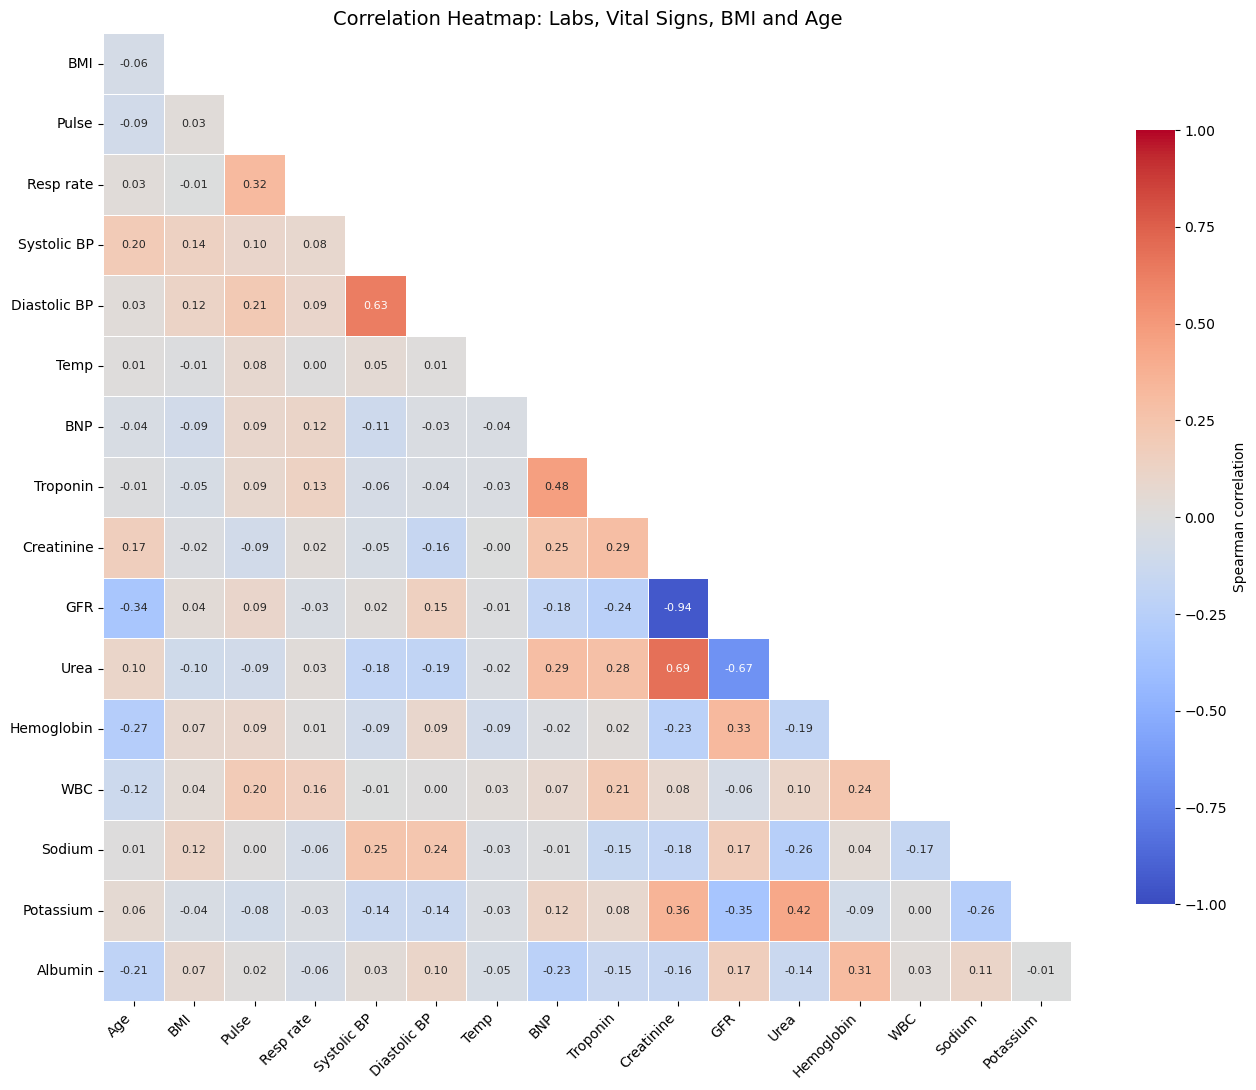

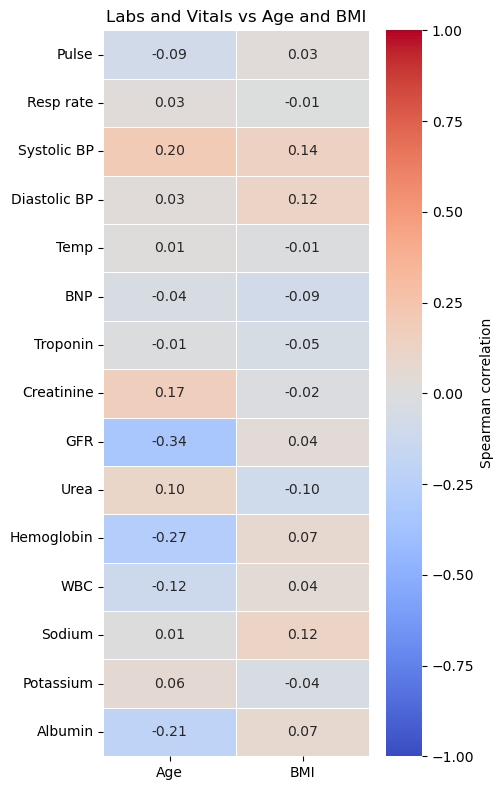


Top 10 strongest correlations:
GFR           Creatinine    -0.94
Urea          Creatinine     0.69
              GFR           -0.67
Diastolic BP  Systolic BP    0.63
Troponin      BNP            0.48
Potassium     Urea           0.42
              Creatinine     0.36
              GFR           -0.35
GFR           Age           -0.34
Hemoglobin    GFR            0.33
dtype: float64


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Age is stored as groups (e.g. "70-79"), so turn it into a number (the group's midpoint)
age_midpoints = {"21-29": 25, "30-39": 35, "40-49": 45, "50-59": 55,
                 "60-69": 65, "70-79": 75, "80-89": 85, "90-110": 95}
df["age_numeric"] = df["age_category"].map(age_midpoints)

# Pick the variables for the heatmap
vitals = ["pulse", "respiration", "systolic_blood_pressure",
          "diastolic_blood_pressure", "body_temperature"]
labs = ["brain_natriuretic_peptide", "high_sensitivity_troponin", "creatinine_enzymatic_method",
        "glomerular_filtration_rate", "urea", "hemoglobin", "white_blood_cell",
        "sodium", "potassium", "albumin"]
demo = ["age_numeric", "bmi"]

corr_cols = demo + vitals + labs

# Shorter names so the heatmap labels are readable
short_names = {
    "age_numeric": "Age", "bmi": "BMI",
    "pulse": "Pulse", "respiration": "Resp rate",
    "systolic_blood_pressure": "Systolic BP", "diastolic_blood_pressure": "Diastolic BP",
    "body_temperature": "Temp",
    "brain_natriuretic_peptide": "BNP", "high_sensitivity_troponin": "Troponin",
    "creatinine_enzymatic_method": "Creatinine", "glomerular_filtration_rate": "GFR",
    "urea": "Urea", "hemoglobin": "Hemoglobin", "white_blood_cell": "WBC",
    "sodium": "Sodium", "potassium": "Potassium", "albumin": "Albumin",
}

# Missing values per column (correlation uses all available pairs)
print("Missing values:")
print(df[corr_cols].isna().sum())

# Spearman correlation — better than Pearson here because many labs are skewed
corr = df[corr_cols].corr(method="spearman").rename(index=short_names, columns=short_names)
print(corr.round(2))

# Heatmap 1 — full correlation matrix (lower triangle only)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 11))
sns.heatmap(corr.iloc[1:, :-1], mask=mask[1:, :-1], annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.8, "label": "Spearman correlation"})
plt.title("Correlation Heatmap: Labs, Vital Signs, BMI and Age", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Heatmap 2 — how each lab and vital relates to Age and BMI
age_bmi = corr.loc[[short_names[c] for c in vitals + labs], ["Age", "BMI"]]
plt.figure(figsize=(5, 8))
sns.heatmap(age_bmi, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            center=0, linewidths=0.5, cbar_kws={"label": "Spearman correlation"})
plt.title("Labs and Vitals vs Age and BMI")
plt.tight_layout()
plt.show()

# Top 10 strongest pairs (positive or negative)
pairs = corr.where(np.tril(np.ones(corr.shape, dtype=bool), k=-1)).stack()
top_pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(10).round(2)
print("\nTop 10 strongest correlations:")
print(top_pairs)

**Analysis:**
Strong biological links exist between Creatinine and GFR (-0.94), Creatinine and Urea (0.69), and BNP and Troponin (0.48), while advancing age correlates with declining kidney function and lower albumin levels.

**Q8: How many medications does the average patient take?**

Reason:
This step helps us understand the overall medication burden among cardiac patients by showing how many medications patients are typically prescribed.

count    2007.00
mean        7.65
std         2.43
min         1.00
25%         6.00
50%         8.00
75%         9.00
max        16.00
Name: drug_count, dtype: float64
Missing drug_count: 1
Average: 7.65 | Median: 8 | Most common: 8
5+ medications: 90.1% | 10+ medications: 22.0%
        mean  median
gender              
Female  7.44     8.0
Male    7.95     8.0
            mean  median
nyha_class              
2           7.25     7.0
3           7.58     8.0
4           8.01     8.0


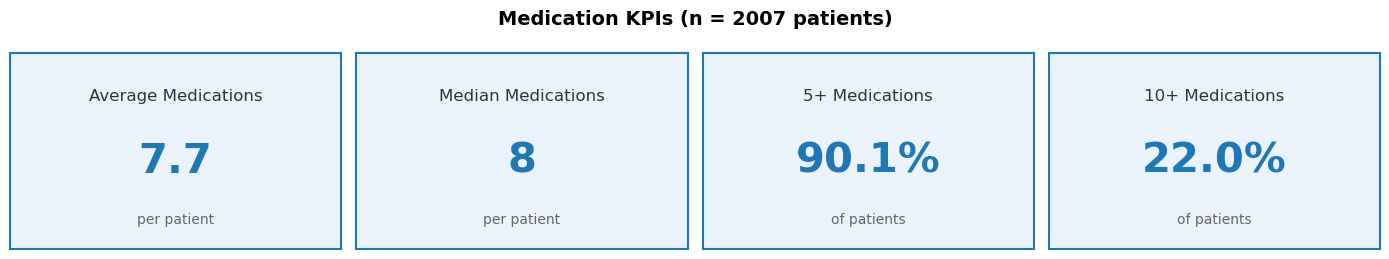

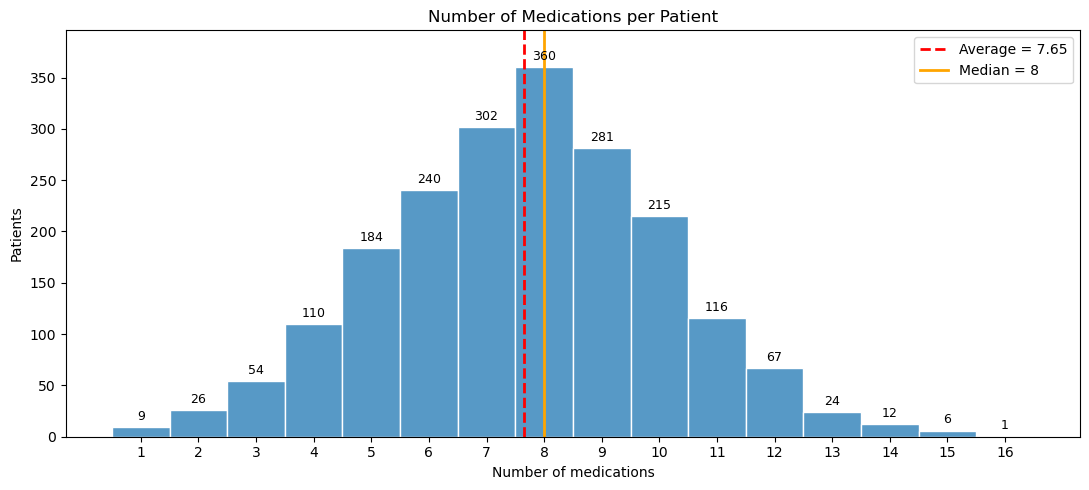

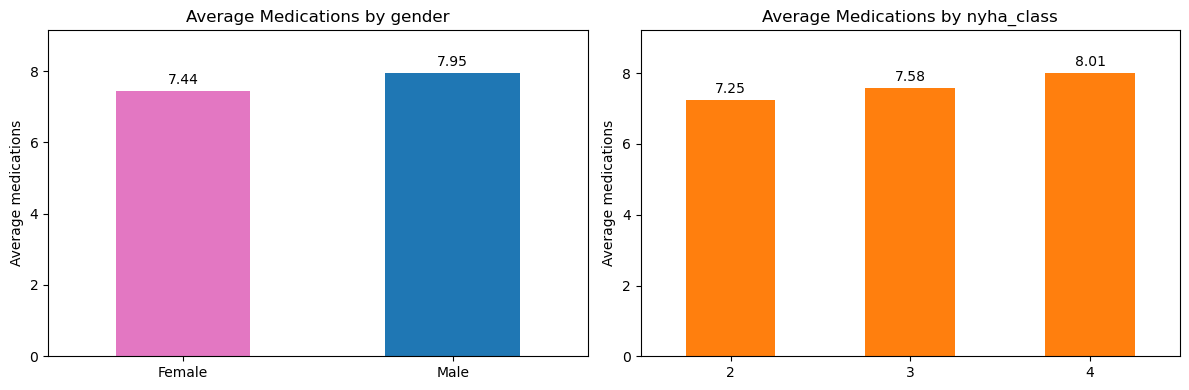

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Medication count summary
meds = df["drug_count"].dropna()
avg_meds = meds.mean()
median_meds = meds.median()
mode_meds = meds.mode()[0]
pct_5_plus = (meds >= 5).mean() * 100
pct_10_plus = (meds >= 10).mean() * 100

print(meds.describe().round(2))
print("Missing drug_count:", df["drug_count"].isna().sum())
print(f"Average: {avg_meds:.2f} | Median: {median_meds:.0f} | Most common: {mode_meds:.0f}")
print(f"5+ medications: {pct_5_plus:.1f}% | 10+ medications: {pct_10_plus:.1f}%")

# Average medications by gender and NYHA class
print(df.groupby("gender")["drug_count"].agg(["mean", "median"]).round(2))
print(df.groupby("nyha_class")["drug_count"].agg(["mean", "median"]).round(2))

# KPI cards
kpis = [
    ("Average Medications", f"{avg_meds:.1f}", "per patient"),
    ("Median Medications", f"{median_meds:.0f}", "per patient"),
    ("5+ Medications", f"{pct_5_plus:.1f}%", "of patients"),
    ("10+ Medications", f"{pct_10_plus:.1f}%", "of patients"),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 2.6))
for ax, (title, value, sub) in zip(axes, kpis):
    ax.set_facecolor("#eaf2fb")
    ax.text(0.5, 0.78, title, ha="center", va="center", fontsize=12, color="#333333")
    ax.text(0.5, 0.45, value, ha="center", va="center", fontsize=30, fontweight="bold", color="#1f77b4")
    ax.text(0.5, 0.15, sub, ha="center", va="center", fontsize=10, color="#666666")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#1f77b4")
        spine.set_linewidth(1.5)
plt.suptitle(f"Medication KPIs (n = {len(meds)} patients)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Histogram — number of medications per patient
plt.figure(figsize=(11, 5))
ax = sns.histplot(meds, discrete=True, color="#1f77b4", edgecolor="white")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
plt.axvline(avg_meds, color="red", linestyle="--", linewidth=2, label=f"Average = {avg_meds:.2f}")
plt.axvline(median_meds, color="orange", linestyle="-", linewidth=2, label=f"Median = {median_meds:.0f}")
plt.title("Number of Medications per Patient")
plt.xlabel("Number of medications")
plt.ylabel("Patients")
plt.xticks(range(int(meds.min()), int(meds.max()) + 1))
plt.legend()
plt.margins(y=0.1)
plt.tight_layout()
plt.show()

# Bar graph — average medications by gender and NYHA class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, colors in zip(axes, ["gender", "nyha_class"],
                           [["#e377c2", "#1f77b4"], ["#ff7f0e"]]):
    avg = df.groupby(col)["drug_count"].mean().round(2)
    avg.plot(kind="bar", ax=ax, color=colors)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)
    ax.set_title(f"Average Medications by {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Average medications")
    ax.tick_params(axis="x", rotation=0)
    ax.margins(y=0.15)
plt.tight_layout()
plt.show()

**Analysis:**
Patients taking an average of 7.65 medications, 90.1% taking 5 or more drugs, and medication burden tracking directly upward with advancing heart failure severity. Since vast majority of patients at an exceptionally high risk considering the medications count hence need a medication review

**Q9: How many cardiac patients were readmitted within 28 days, 3 months, and 6 months?**

Reason:
This step helps us understand how often cardiac patients return to the hospital after their initial hospitalization and how readmissions change across the 28-day, 3-month, and 6-month periods.

          readmitted     %
28 days          140   7.0
3 months         498  24.8
6 months         773  38.5
Missing values: 0
Readmitted at 3 months but not at 6 months (data issue): 3
gender    Female  Male
28 days       72    68
3 months     284   214
6 months     438   335
gender    Female  Male
28 days      6.2   8.0
3 months    24.4  25.3
6 months    37.7  39.6


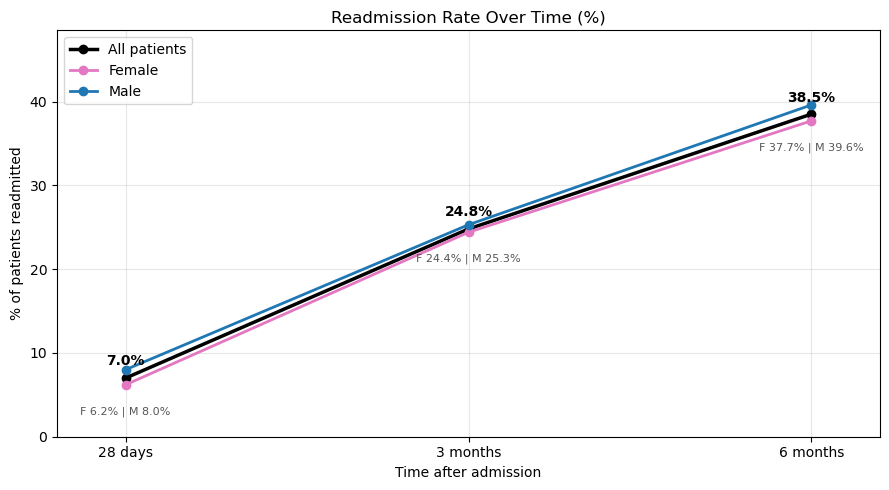

In [15]:
import matplotlib.pyplot as plt

readmit_cols = ["re_admission_within_28_days", "re_admission_within_3_months", "re_admission_within_6_months"]
labels = ["28 days", "3 months", "6 months"]

# Readmission counts and %
readmit_table = pd.DataFrame({
    "readmitted": df[readmit_cols].sum().values,
    "%": (df[readmit_cols].mean() * 100).round(1).values
}, index=labels)
print(readmit_table)
print("Missing values:", df[readmit_cols].isna().sum().sum())

# Data check: readmitted at 3 months should also be readmitted at 6 months
check = df[(df["re_admission_within_3_months"] == 1) & (df["re_admission_within_6_months"] == 0)]
print("Readmitted at 3 months but not at 6 months (data issue):", len(check))

# Readmission by gender (counts and %)
readmit_gender_n = df.groupby("gender")[readmit_cols].sum().T
readmit_gender_n.index = labels
readmit_gender_pct = (df.groupby("gender")[readmit_cols].mean() * 100).round(1).T
readmit_gender_pct.index = labels
print(readmit_gender_n)
print(readmit_gender_pct)

# Line chart — readmission rate over time, overall and by gender
plt.figure(figsize=(9, 5))
plt.plot(labels, readmit_table["%"], marker="o", linewidth=2.5, color="black", label="All patients")
plt.plot(labels, readmit_gender_pct["Female"], marker="o", linewidth=2, color="#e377c2", label="Female")
plt.plot(labels, readmit_gender_pct["Male"], marker="o", linewidth=2, color="#1f77b4", label="Male")
for x, y in zip(labels, readmit_table["%"]):
    plt.text(x, y + 1.5, f"{y}%", ha="center", fontsize=10, fontweight="bold")
for x, f, m in zip(labels, readmit_gender_pct["Female"], readmit_gender_pct["Male"]):
    plt.text(x, min(f, m) - 3.5, f"F {f}% | M {m}%", ha="center", fontsize=8, color="#555555")
plt.title("Readmission Rate Over Time (%)")
plt.xlabel("Time after admission")
plt.ylabel("% of patients readmitted")
plt.ylim(0, readmit_table["%"].max() + 10)
plt.margins(x=0.1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis:**
Hospital readmission rates escalate over time, rising from 7.0% at 28 days to 24.8% at 3 months, and peaking at a costly 38.5% within 6 months, with no meaningful differences between genders.The massive spike in readmissions between 1 and 3 months highlights a critical post-discharge vulnerability window where transitional care and outpatient monitoring must be reinforced.

**Q10: What are the overall in-hospital, 28-day, 3-month, and 6-month mortality rates?**

Reason:
This step helps us understand how patient mortality changes from hospitalization through different follow-up periods and provides a clear picture of overall patient outcomes.

             deaths     %
In-hospital      11  0.55
28 days          37  1.84
3 months         42  2.09
6 months         57  2.84
Missing values: 0
gender       Female  Male
In-hospital     0.2   1.1
28 days         1.4   2.5
3 months        1.5   2.8
6 months        2.4   3.4
destination_discharge           Died  Health care Facility  Home  Unknown
outcome_during_hospitalization                                           
Alive                              5                   424  1301      160
Dead                               9                     0     1        1
Discharge Against Order            0                    14    42       51


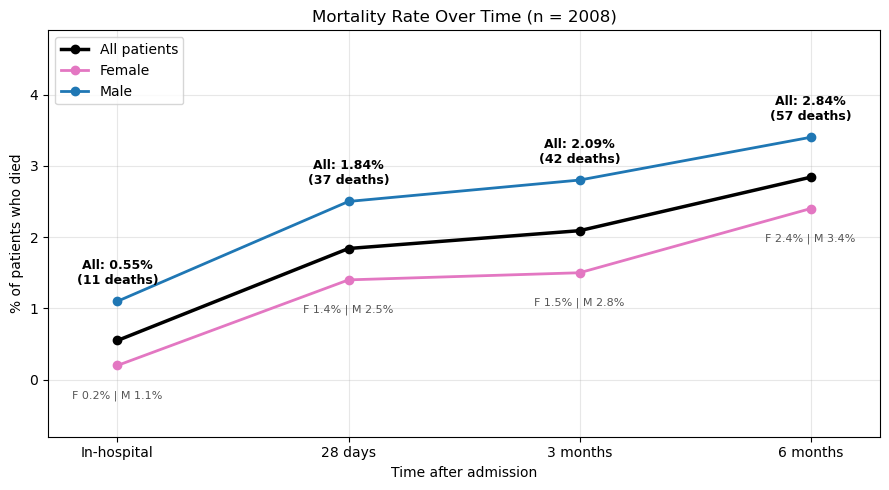

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# In-hospital death flag (1 = died during hospitalization)
df["death_in_hospital"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)

mort_cols = ["death_in_hospital", "death_within_28_days", "death_within_3_months", "death_within_6_months"]
labels = ["In-hospital", "28 days", "3 months", "6 months"]

# Mortality counts and rates
mort_table = pd.DataFrame({
    "deaths": df[mort_cols].sum().values,
    "%": (df[mort_cols].mean() * 100).round(2).values
}, index=labels)
print(mort_table)
print("Missing values:", df[mort_cols].isna().sum().sum())

# Mortality by gender (%)
mort_gender = (df.groupby("gender")[mort_cols].mean() * 100).round(1).T
mort_gender.index = labels
print(mort_gender)

# Data check: in-hospital outcome vs discharge destination
print(pd.crosstab(df["outcome_during_hospitalization"], df["destination_discharge"]))

# Line chart — mortality rate over time, overall and by gender
plt.figure(figsize=(9, 5))
plt.plot(labels, mort_table["%"], marker="o", linewidth=2.5, color="black", label="All patients")
plt.plot(labels, mort_gender["Female"], marker="o", linewidth=2, color="#e377c2", label="Female")
plt.plot(labels, mort_gender["Male"], marker="o", linewidth=2, color="#1f77b4", label="Male")
for x, y, n in zip(labels, mort_table["%"], mort_table["deaths"]):
    top = mort_gender.loc[x].max()
    plt.text(x, top + 0.2, f"All: {y}%\n({n} deaths)", ha="center", va="bottom", fontsize=9, fontweight="bold")
for x, f, m in zip(labels, mort_gender["Female"], mort_gender["Male"]):
    plt.text(x, min(f, m) - 0.35, f"F {f}% | M {m}%", ha="center", va="top", fontsize=8, color="#555555")
plt.title(f"Mortality Rate Over Time (n = {len(df)})")
plt.xlabel("Time after admission")
plt.ylabel("% of patients who died")
plt.ylim(-0.8, mort_gender.values.max() + 1.5)
plt.margins(x=0.1)
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Analysis:**
Mortality increases steadily from 0.55% in-hospital to 2.84% at 6 months, with male patients consistently experiencing a significantly higher risk of death than females at every single milestone.While immediate in-hospital survival is high, the sustained rise in post-discharge mortality—particularly among men—underscores the need for more aggressive long-term surveillance.